# Разведочный анализ данных: Give Me Some Credit

**Цель**: первичное знакомство с датасетом, оценка качества данных, формулировка гипотез для предобработки.

**Датасет**: `cs-training.csv` (Kaggle: Give Me Some Credit)  
- Объём: ~150 000 записей  
- Признаки: 10 числовых + 1 целевая  
- Задача: бинарная классификация (дефолт заёмщика)

In [14]:
import sys
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# Настройки
RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
warnings.filterwarnings("ignore")

# Логирование
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)-8s | %(message)s", datefmt="%H:%M:%S")
logger = logging.getLogger(__name__)

# Пути
PROJECT_ROOT = Path().resolve().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"
TRAIN_FILE = "cs-training.csv"
TARGET_COL = "SeriousDlqin2yrs"

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "eda"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
DATA_ARTIFACTS_DIR = ARTIFACTS_DIR / "data"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Окружение настроено")

Окружение настроено


## 1. Загрузка данных
Загружаем датасет `cs-training.csv` с финансовыми показателями заёмщиков.  
Целевая переменная – `SeriousDlqin2yrs` (наличие серьёзной просрочки 90+ дней в течение 2 лет).

In [15]:
df = pd.read_csv(DATA_DIR / TRAIN_FILE)
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

print(f"Данные загружены: {df.shape[0]} строк, {df.shape[1]} столбцов")
df.head()

Данные загружены: 150000 строк, 11 столбцов


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 2. Целевая переменная и дисбаланс классов
Проверим распределение целевой переменной, чтобы оценить степень дисбаланса.

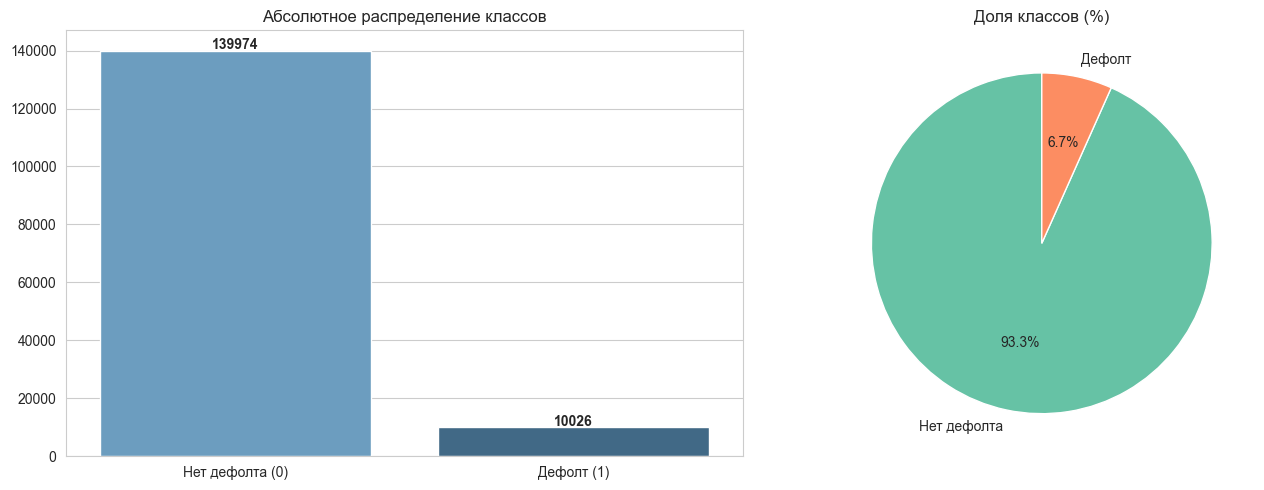

Коэффициент дисбаланса: 13.96:1


In [16]:
target_counts = df[TARGET_COL].value_counts()
target_pct = df[TARGET_COL].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=["Нет дефолта (0)", "Дефолт (1)"], y=target_counts.values, ax=axes[0], palette="Blues_d")
axes[0].set_title("Абсолютное распределение классов")
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, str(v), ha="center", fontweight="bold")

axes[1].pie(target_pct.values, labels=["Нет дефолта", "Дефолт"], autopct="%1.1f%%",
            colors=["#66c2a5", "#fc8d62"], startangle=90)
axes[1].set_title("Доля классов (%)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_target_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

imbalance_ratio = target_counts[0] / target_counts[1]
print(f"Коэффициент дисбаланса: {imbalance_ratio:.2f}:1")

**Вывод:** По распределению видно, что классы неравномерны: не-дефолтов около 93%, дефолтов — около 7%. Это довольно сильный перекос, типичный для задач кредитного скоринга. Значит, обычная accuracy тут не подойдёт — модель может просто всегда говорить «не дефолт» и всё равно получать высокую долю правильных ответов. Лучше опираться на ROC‑AUC, а при обучении использовать `class_weight='balanced'`, чтобы алгоритм не игнорировал миноритарный класс.

## 3. Пропущенные значения
Анализируем наличие пропусков и их долю по признакам.

Пропуски в 2 признаках:


,missing_count,missing_pct
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62


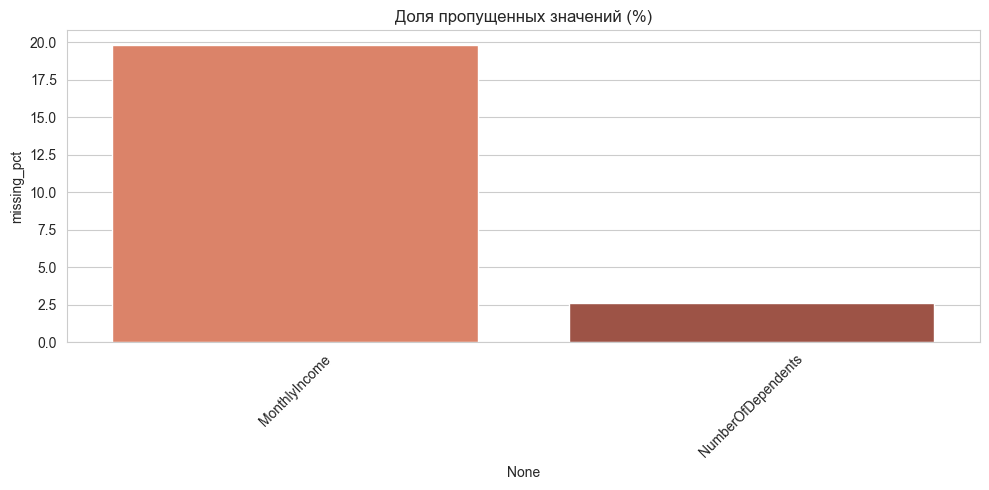

In [17]:
missing_stats = df.isnull().sum()
missing_pct = (missing_stats / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing_stats, "missing_pct": missing_pct})
missing_df = missing_df.query("missing_count > 0").sort_values("missing_pct", ascending=False)

if not missing_df.empty:
    print(f"Пропуски в {len(missing_df)} признаках:")
    display(missing_df)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing_df.index, y=missing_df["missing_pct"], palette="OrRd_d")
    plt.title("Доля пропущенных значений (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "02_missing_values.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    missing_df.to_csv(DATA_ARTIFACTS_DIR / "missing_values_report.csv")
else:
    print("Пропусков нет.")

**Вывод:** Пропуски обнаружились в двух признаках: `MonthlyIncome` (почти 20%) и `NumberOfDependents` (около 2.6%). Для дохода пропусков многовато, просто выбросить их нельзя — потеряем много информации. Думаю, медианная импутация будет нормальным вариантом: медиана устойчивее среднего к выбросам, которых в доходе хватает. Для иждивенцев тоже сработает медиана или мода.

## 4. Описательная статистика и распределения признаков
Смотрим статистические характеристики, выявляем перекосы и выбросы, визуализируем ключевые признаки.

In [18]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(TARGET_COL)
stats_df = df[numeric_cols].describe().T
stats_df["skewness"] = df[numeric_cols].skew().round(3)
stats_df["null_count"] = df[numeric_cols].isnull().sum()
display(stats_df[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "skewness", "null_count"]])
stats_df.to_csv(DATA_ARTIFACTS_DIR / "feature_statistics.csv")

,count,mean,std,min,25%,50%,75%,max,skewness,null_count
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0,97.632,0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0,0.189,0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0,22.597,0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0,95.158,0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0,114.040,29731
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0,1.215,0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0,23.087,0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0,3.482,0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0,23.332,0
NumberOfDependents,146076.0,0.757222,1.115086,0.0,0.000000,0.000000,1.000000,20.0,1.588,3924


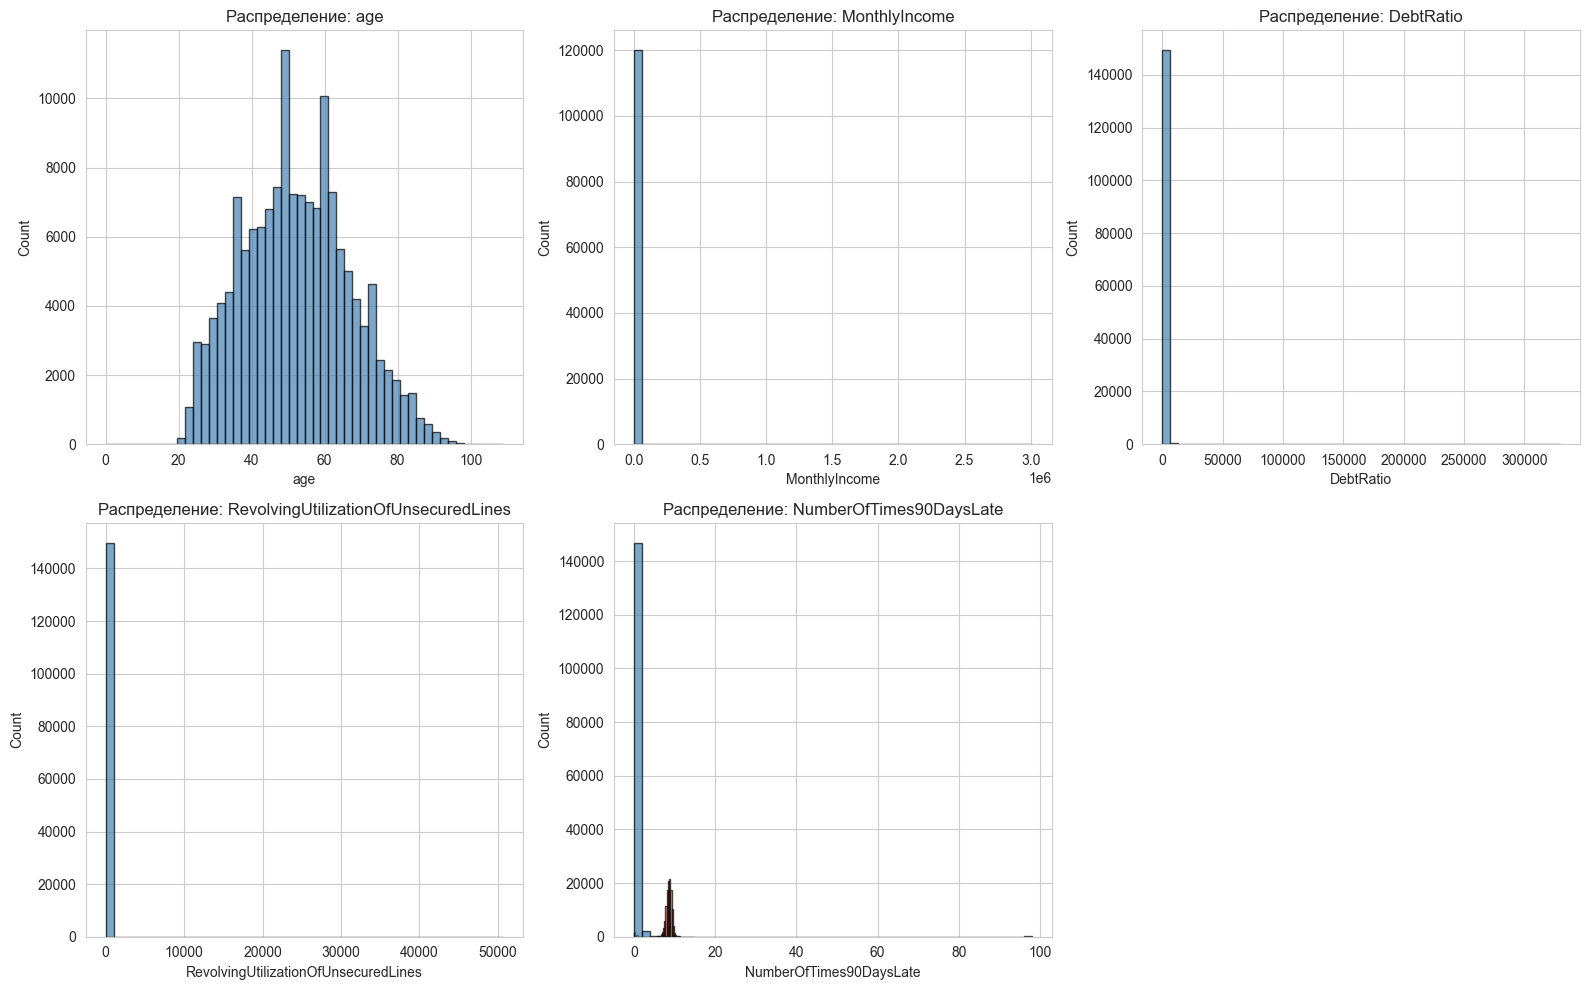

In [19]:
key_features = ["age", "MonthlyIncome", "DebtRatio", "RevolvingUtilizationOfUnsecuredLines", "NumberOfTimes90DaysLate"]
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(key_features):
    data = df[col].dropna()
    ax = axes[idx]
    ax.hist(data, bins=50, edgecolor="black", alpha=0.7, color="steelblue")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.set_title(f"Распределение: {col}")

    if data.max() / (data.median() + 1e-6) > 100:
        ax2 = axes[idx + 3] if idx + 3 < len(axes) else None
        if ax2:
            ax2.hist(np.log1p(data), bins=50, edgecolor="black", alpha=0.7, color="coral")
            ax2.set_xlabel(f"{col} (log-transformed)")
            ax2.set_title(f"Лог-распределение: {col}")

for idx in range(len(key_features), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_feature_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

**Вывод:** Бросается в глаза, что несколько финансовых показателей (`RevolvingUtilizationOfUnsecuredLines`, `DebtRatio`, `MonthlyIncome`) имеют просто гигантский перекос — skewness зашкаливает за 95. Это хорошо видно на гистограммах: основная масса значений сконцентрирована вблизи нуля, но есть длинный хвост выбросов. Чтобы распределения стали более «нормальными» и модели работали устойчивее, попробую логарифмическую трансформацию (`log1p`). Она часто помогает в таких случаях.

## 5. Корреляционный анализ
Изучаем линейные связи признаков с целевой переменной и между собой.

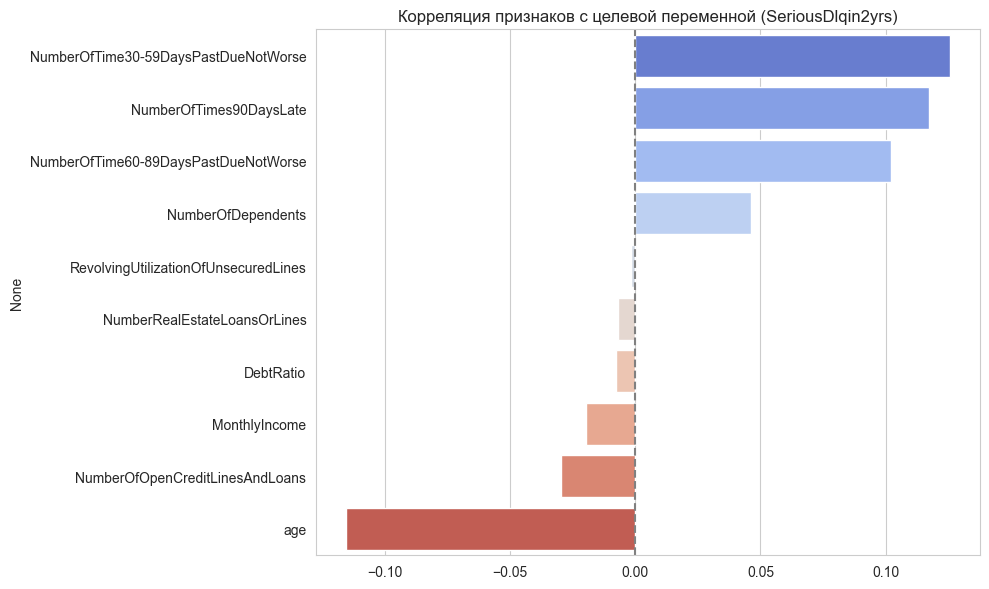

In [20]:
correlations = df[numeric_cols].corrwith(df[TARGET_COL]).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=correlations.values, y=correlations.index, palette="coolwarm")
plt.title("Корреляция признаков с целевой переменной (SeriousDlqin2yrs)")
plt.axvline(x=0, color="gray", linestyle="--")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_target_correlations.png", dpi=300, bbox_inches='tight')
plt.show()

correlations.to_frame("pearson_correlation").to_csv(DATA_ARTIFACTS_DIR / "target_correlations.csv")

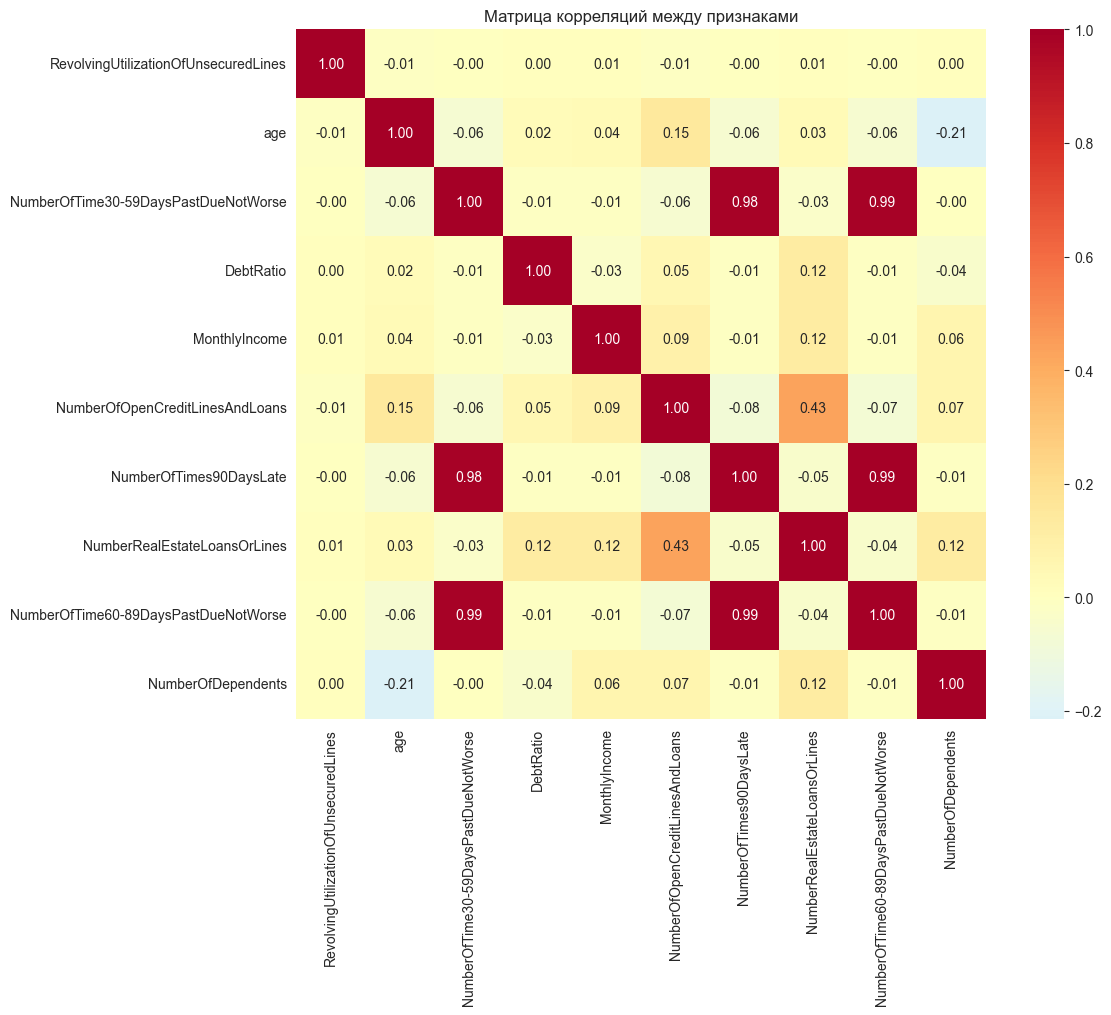

Обнаружены пары с |r|>0.8: 3


In [21]:
plt.figure(figsize=(12, 10))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlBu_r", center=0, square=True)
plt.title("Матрица корреляций между признаками")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_correlation_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs, columns=["feature_1", "feature_2", "correlation"])
    high_corr_df.to_csv(DATA_ARTIFACTS_DIR / "high_correlation_pairs.csv", index=False)
    print(f"Обнаружены пары с |r|>0.8: {len(high_corr_df)}")
else:
    print("Сильных корреляций между признаками не обнаружено.")

**Вывод:** Бросается в глаза, что несколько финансовых показателей (`RevolvingUtilizationOfUnsecuredLines`, `DebtRatio`, `MonthlyIncome`) имеют просто гигантский перекос — skewness зашкаливает за 95. Это хорошо видно на гистограммах: основная масса значений сконцентрирована вблизи нуля, но есть длинный хвост выбросов. Чтобы распределения стали более «нормальными» и модели работали устойчивее, попробую логарифмическую трансформацию (`log1p`). Она часто помогает в таких случаях.

## 6. Анализ выбросов (метод IQR)
Для финансовых признаков оценим количество и границы выбросов.

,feature,outliers,outlier_pct,iqr_lower,iqr_upper
0,RevolvingUtilizationOfUnsecuredLines,763,0.51,-0.763901,1.352814
1,DebtRatio,31311,20.87,-0.864696,1.908024
2,MonthlyIncome,4879,4.06,-3873.500000,15522.500000


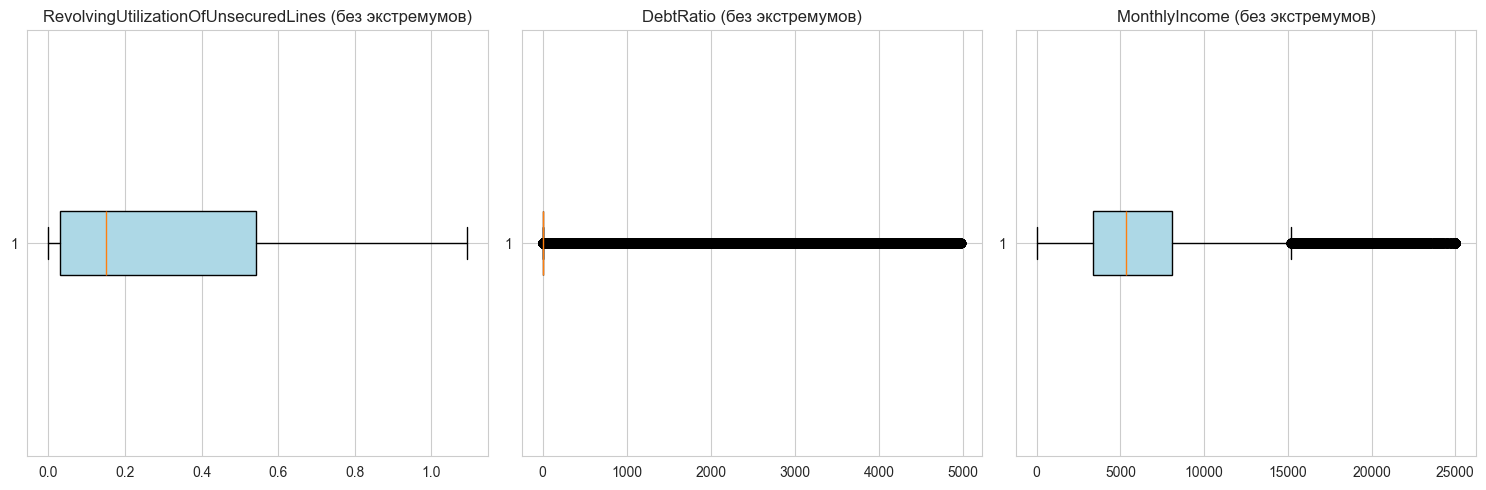

In [22]:
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((series < lower) | (series > upper)).sum()
    return int(outliers), float(lower), float(upper), round(outliers / len(series) * 100, 2)

financial_cols = ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio", "MonthlyIncome"]
outlier_report = []
for col in financial_cols:
    if col in df.columns:
        n_out, low, high, pct = detect_outliers_iqr(df[col].dropna())
        outlier_report.append({"feature": col, "outliers": n_out, "outlier_pct": pct, "iqr_lower": low, "iqr_upper": high})

outlier_df = pd.DataFrame(outlier_report)
display(outlier_df)
outlier_df.to_csv(DATA_ARTIFACTS_DIR / "outliers_iqr_report.csv", index=False)

fig, axes = plt.subplots(1, len(financial_cols), figsize=(15, 5))
for ax, col in zip(axes, financial_cols):
    data = df[col].dropna()
    ax.boxplot(data[data <= data.quantile(0.99)], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
    ax.set_title(f"{col} (без экстремумов)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_outliers_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

**Вывод:** Посмотрел на выбросы через межквартильный размах. В `DebtRatio` доля выбросов превысила 20% — немало, признак явно «грязный». У `MonthlyIncome` около 4% выбросов, что тоже чувствительно. Обычный `StandardScaler` в такой ситуации может сместить среднее и стандартное отклонение. Поэтому позже, на этапе предобработки, возьму `RobustScaler` — он использует медиану и квартили, так что на выбросы реагирует меньше.

## 7. Baseline – DummyClassifier
Оцениваем нижнюю границу качества с помощью классификатора, предсказывающего самый частый класс.

In [23]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred = dummy.predict(X_test)
y_proba = dummy.predict_proba(X_test)[:, 1]

print("Baseline (DummyClassifier most_frequent):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1: {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(classification_report(y_test, y_pred, target_names=["Нет дефолта", "Дефолт"], zero_division=0))

Baseline (DummyClassifier most_frequent):
Accuracy: 0.9332
F1: 0.0000
ROC-AUC: 0.5000
              precision    recall  f1-score   support

 Нет дефолта       0.93      1.00      0.97     27995
      Дефолт       0.00      0.00      0.00      2005

    accuracy                           0.93     30000
   macro avg       0.47      0.50      0.48     30000
weighted avg       0.87      0.93      0.90     30000



In [24]:
print("EDA завершён. Артефакты сохранены в artifacts/eda/")

EDA завершён. Артефакты сохранены в artifacts/eda/


**Вывод:** Ожидаемо, что DummyClassifier, который тупо предсказывает самый частый класс, показал нулевое качество для миноритарного класса (F1=0) и ROC‑AUC на уровне случайного угадывания (0.5). Это нормально — так и должно быть. Теперь у нас есть нижняя граница, и дальше интересно посмотреть, насколько настоящие модели смогут её превзойти.